# 06 · Pipeline Consolidation, Deployment & Monitoring

**What's covered:**
1. One end-to-end `Pipeline` — raw customer data in, prediction out, feature engineering included — not a notebook-only workflow
2. Serialization with `joblib` and a load-and-predict round trip
3. A `predict_churn_risk()` scoring function simulating what a real scoring service does
4. A minimal FastAPI app, written to a real file
5. Population Stability Index (PSI) drift monitoring, demonstrated on both a no-drift and a genuinely drifted case
6. A model card
7. What a real production setup adds beyond this notebook

Self-contained: reads the raw CSV and rebuilds everything from scratch, using the same `random_state=42` split and the same tuned XGBoost hyperparameters as Notebooks 3-5.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import json
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, recall_score, precision_score
import xgboost as xgb

pd.set_option('display.width', 140)
pd.set_option('display.max_columns', 40)
sns.set_style('whitegrid')
RANDOM_STATE = 42

## 1. Load & split — raw data only. Feature engineering moves *inside* the pipeline this time.

In [2]:
def load_and_clean(path='WA_FnUseC_TelcoCustomerChurn.csv'):
    df = pd.read_csv(path)
    df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan).astype(float)
    df['TotalCharges'] = df['TotalCharges'].fillna(0.0)
    df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
    df = df.drop(columns=['customerID'])
    return df

def engineer_features(df):
    df = df.copy()
    df['tenure_bucket'] = pd.cut(
        df['tenure'], bins=[-1, 12, 24, 36, 48, 60, 72],
        labels=['0-12', '13-24', '25-36', '37-48', '49-60', '61-72']
    ).astype(str)
    df['charges_per_tenure_ratio'] = np.where(
        df['tenure'] > 0, df['TotalCharges'] / df['tenure'], df['MonthlyCharges']
    )
    df['monthly_charge_delta'] = df['MonthlyCharges'] - df['charges_per_tenure_ratio']
    df['contract_payment'] = df['Contract'] + '_' + df['PaymentMethod']
    addon_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                  'TechSupport', 'StreamingTV', 'StreamingMovies']
    df['num_addon_services'] = (df[addon_cols] == 'Yes').sum(axis=1)
    df['is_new_customer'] = (df['tenure'] <= 3).astype(int)
    return df

raw = load_and_clean()
X_raw = raw.drop(columns=['Churn'])
y = raw['Churn']
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print(f"Train: {X_train_raw.shape}  Test: {X_test_raw.shape}")
print("Note: X_train_raw/X_test_raw have NOT had engineer_features applied — that step is now part of the pipeline itself.")

Train: (5634, 19)  Test: (1409, 19)
Note: X_train_raw/X_test_raw have NOT had engineer_features applied — that step is now part of the pipeline itself.


## 2. One pipeline, raw data to prediction

Every model in Notebooks 3-5 assumed `engineer_features()` had already been run — fine for a notebook where every cell shares the same DataFrame, not fine for a scoring service that receives one raw customer record at a time. Wrapping `engineer_features` in a `FunctionTransformer` folds it into the `Pipeline` itself, so the whole thing — feature engineering, preprocessing, model — is one object with a single `.fit()`/`.predict_proba()` contract.

In [3]:
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'charges_per_tenure_ratio',
                'monthly_charge_delta', 'num_addon_services', 'SeniorCitizen']
categorical_cols = [c for c in engineer_features(X_train_raw.head(2)).columns if c not in numeric_cols]

full_pipeline = Pipeline([
    ('feature_engineering', FunctionTransformer(engineer_features)),
    ('preprocessing', ColumnTransformer([
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
    ])),
    ('clf', xgb.XGBClassifier(
        n_estimators=188, max_depth=3, learning_rate=0.059, subsample=0.72, colsample_bytree=0.84,
        min_child_weight=4, reg_alpha=0.97, reg_lambda=2.12, eval_metric='logloss', random_state=RANDOM_STATE
    ))
])

full_pipeline.fit(X_train_raw, y_train)
proba_test = full_pipeline.predict_proba(X_test_raw)[:, 1]
pred_test = (proba_test >= 0.5).astype(int)

print(f"ROC-AUC: {roc_auc_score(y_test, proba_test):.4f}  (matches Notebooks 3-5's numbers — same model, same data, just repackaged as one object)")
print(f"PR-AUC:  {average_precision_score(y_test, proba_test):.4f}")
print(f"F1:      {f1_score(y_test, pred_test):.4f}")

ROC-AUC: 0.8462  (matches Notebooks 3-5's numbers — same model, same data, just repackaged as one object)
PR-AUC:  0.6629
F1:      0.5875


## 3. Serialization

`joblib.dump` on the whole pipeline is enough to persist feature engineering, preprocessing, and the model together — anyone loading this file back doesn't need to know or re-implement any of the steps that produced it. A metadata sidecar file travels with it: which threshold to use, when it was trained, and a performance snapshot, none of which belong baked into the model object itself.

In [4]:
BUSINESS_THRESHOLD = 0.20  # from Notebook 4's cost-based threshold analysis

joblib.dump(full_pipeline, 'churn_pipeline.joblib')

metadata = {
    'model_version': '1.0.0',
    'trained_at': datetime.now().strftime('%Y-%m-%d'),
    'training_rows': int(len(X_train_raw)),
    'business_threshold': BUSINESS_THRESHOLD,
    'test_set_metrics': {
        'roc_auc': round(float(roc_auc_score(y_test, proba_test)), 4),
        'pr_auc': round(float(average_precision_score(y_test, proba_test)), 4),
        'f1_at_0.5': round(float(f1_score(y_test, pred_test)), 4),
    },
    'feature_columns_expected': list(X_train_raw.columns),
}
with open('churn_model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print(json.dumps(metadata, indent=2))

{
  "model_version": "1.0.0",
  "trained_at": "2026-09-12",
  "training_rows": 5634,
  "business_threshold": 0.2,
  "test_set_metrics": {
    "roc_auc": 0.8462,
    "pr_auc": 0.6629,
    "f1_at_0.5": 0.5875
  },
  "feature_columns_expected": [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "tenure",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod",
    "MonthlyCharges",
    "TotalCharges"
  ]
}


In [5]:
# Round trip: load from disk, predict on a few raw rows, confirm it matches the in-memory pipeline
loaded_pipeline = joblib.load('churn_pipeline.joblib')
sample = X_test_raw.iloc[:3]
original_preds = full_pipeline.predict_proba(sample)[:, 1]
loaded_preds = loaded_pipeline.predict_proba(sample)[:, 1]
print("Original :", np.round(original_preds, 5))
print("Reloaded :", np.round(loaded_preds, 5))
print("Identical:", np.allclose(original_preds, loaded_preds))

Original : [0.04376 0.82251 0.08474]
Reloaded : [0.04376 0.82251 0.08474]
Identical: True


## 4. A scoring function

What a real scoring service does on each request: take one raw record (same shape as an API payload or a CRM export row), run it through the pipeline, and translate the probability into something a retention team can act on — not just a number.

In [6]:
def predict_churn_risk(customer: dict, pipeline=None, threshold=BUSINESS_THRESHOLD) -> dict:
    """Score a single customer record (raw schema, same columns as the source CSV minus
    customerID/Churn) and return a probability, risk tier, and recommended action."""
    if pipeline is None:
        pipeline = loaded_pipeline
    row = pd.DataFrame([customer])
    proba = float(pipeline.predict_proba(row)[0, 1])

    if proba >= 0.5:
        tier, action = 'High', 'Immediate outreach — priority retention offer'
    elif proba >= threshold:
        tier, action = 'Elevated', 'Include in next retention campaign batch'
    else:
        tier, action = 'Low', 'No action needed'

    return {'churn_probability': round(proba, 4), 'risk_tier': tier,
            'flagged_at_business_threshold': proba >= threshold, 'recommended_action': action}

example_customer = X_test_raw.iloc[0].to_dict()
result = predict_churn_risk(example_customer)
print(f"Actual outcome for this customer: {'Churned' if y_test.iloc[0] == 1 else 'Stayed'}")
print(json.dumps(result, indent=2))

Actual outcome for this customer: Stayed
{
  "churn_probability": 0.0438,
  "risk_tier": "Low",
  "flagged_at_business_threshold": false,
  "recommended_action": "No action needed"
}


## 5. A minimal FastAPI app

Not runnable inside a notebook (there's no server process to attach to here), but a real, complete, correct file — `uvicorn app:app --reload` from a terminal with the two artifacts from Section 3 in the same directory is enough to serve it.

In [7]:
%%writefile app.py
"""Minimal churn-scoring API. Run with: uvicorn app:app --reload
Expects churn_pipeline.joblib and churn_model_metadata.json in the same directory."""
import json
import joblib
import pandas as pd
from fastapi import FastAPI
from pydantic import BaseModel

app = FastAPI(title="Telco Churn Scoring API")
pipeline = joblib.load("churn_pipeline.joblib")
with open("churn_model_metadata.json") as f:
    METADATA = json.load(f)


class Customer(BaseModel):
    gender: str
    SeniorCitizen: int
    Partner: str
    Dependents: str
    tenure: int
    PhoneService: str
    MultipleLines: str
    InternetService: str
    OnlineSecurity: str
    OnlineBackup: str
    DeviceProtection: str
    TechSupport: str
    StreamingTV: str
    StreamingMovies: str
    Contract: str
    PaperlessBilling: str
    PaymentMethod: str
    MonthlyCharges: float
    TotalCharges: float


@app.get("/health")
def health():
    return {"status": "ok", "model_version": METADATA["model_version"]}


@app.post("/predict")
def predict(customer: Customer):
    row = pd.DataFrame([customer.model_dump()])
    proba = float(pipeline.predict_proba(row)[0, 1])
    threshold = METADATA["business_threshold"]
    tier = "High" if proba >= 0.5 else ("Elevated" if proba >= threshold else "Low")
    return {"churn_probability": round(proba, 4), "risk_tier": tier,
            "flagged_at_business_threshold": proba >= threshold}

Overwriting app.py


In [8]:
requirements = """fastapi
uvicorn[standard]
pydantic
pandas
numpy
scikit-learn
xgboost
joblib
"""
with open('requirements.txt', 'w') as f:
    f.write(requirements)
print(requirements)

fastapi
uvicorn[standard]
pydantic
pandas
numpy
scikit-learn
xgboost
joblib



## 6. Monitoring: has the incoming population drifted?

A model's training-time performance doesn't stay valid forever — the customer population, pricing, and competitive landscape all shift after deployment. Population Stability Index (PSI) is a standard way to detect that shift without needing fresh labels (which, for churn, might not exist for months): compare the distribution of a score or a feature between the training population and a new incoming batch.

PSI < 0.1 is conventionally read as no meaningful shift, 0.1-0.25 as moderate shift worth watching, and > 0.25 as a shift serious enough to investigate before trusting the model's output.

In [9]:
def population_stability_index(expected, actual, bins=10):
    """PSI between two 1-D numeric arrays. `expected` is the reference (training-time)
    distribution; `actual` is the new population being checked against it."""
    breakpoints = np.percentile(expected, np.linspace(0, 100, bins + 1))
    breakpoints = np.unique(breakpoints)
    breakpoints[0], breakpoints[-1] = -np.inf, np.inf

    e_counts, _ = np.histogram(expected, bins=breakpoints)
    a_counts, _ = np.histogram(actual, bins=breakpoints)
    e_pct = np.clip(e_counts / len(expected), 1e-4, None)
    a_pct = np.clip(a_counts / len(actual), 1e-4, None)
    return float(np.sum((a_pct - e_pct) * np.log(a_pct / e_pct)))

**Case 1 — the honest baseline.** `X_test` is drawn from the exact same source population as `X_train` (a random split of the same dataset) — PSI on both the model's predicted-score distribution and a key raw feature should come back low, and this is worth checking explicitly rather than assumed, since a monitoring function that can't correctly report "no drift" when there isn't any can't be trusted to report real drift either.

**Case 2 — genuine drift, constructed deliberately.** A synthetic "new batch" built by filtering `X_test` down to a specific, non-representative subgroup (fiber-optic customers only) — a stand-in for what a real shift in the customer mix (a marketing push into a specific segment, a regional expansion) would produce.

In [10]:
train_scores = full_pipeline.predict_proba(X_train_raw)[:, 1]
test_scores = full_pipeline.predict_proba(X_test_raw)[:, 1]
drifted_batch = X_test_raw[X_test_raw['InternetService'] == 'Fiber optic']
drifted_scores = full_pipeline.predict_proba(drifted_batch)[:, 1]

psi_score_nodrift = population_stability_index(train_scores, test_scores)
psi_score_drift = population_stability_index(train_scores, drifted_scores)
psi_feature_nodrift = population_stability_index(X_train_raw['MonthlyCharges'], X_test_raw['MonthlyCharges'])
psi_feature_drift = population_stability_index(X_train_raw['MonthlyCharges'], drifted_batch['MonthlyCharges'])

def psi_flag(v):
    return 'no meaningful shift' if v < 0.1 else ('moderate shift' if v < 0.25 else 'significant shift')

print(f"{'Check':45s} {'PSI':>8s}  Interpretation")
print(f"{'Predicted score, train vs. real test':45s} {psi_score_nodrift:8.4f}  {psi_flag(psi_score_nodrift)}")
print(f"{'Predicted score, train vs. fiber-only batch':45s} {psi_score_drift:8.4f}  {psi_flag(psi_score_drift)}")
print(f"{'MonthlyCharges, train vs. real test':45s} {psi_feature_nodrift:8.4f}  {psi_flag(psi_feature_nodrift)}")
print(f"{'MonthlyCharges, train vs. fiber-only batch':45s} {psi_feature_drift:8.4f}  {psi_flag(psi_feature_drift)}")

Check                                              PSI  Interpretation
Predicted score, train vs. real test            0.0139  no meaningful shift
Predicted score, train vs. fiber-only batch     0.8197  significant shift
MonthlyCharges, train vs. real test             0.0125  no meaningful shift
MonthlyCharges, train vs. fiber-only batch      3.0683  significant shift


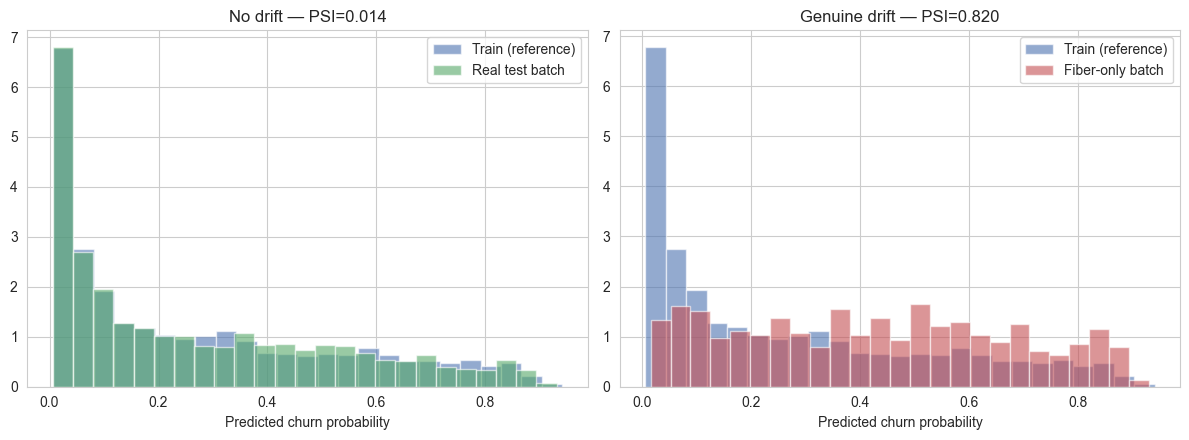

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].hist(train_scores, bins=25, alpha=0.6, density=True, label='Train (reference)', color='#4C72B0')
axes[0].hist(test_scores, bins=25, alpha=0.6, density=True, label='Real test batch', color='#55A868')
axes[0].set_title(f'No drift — PSI={psi_score_nodrift:.3f}')
axes[0].legend()

axes[1].hist(train_scores, bins=25, alpha=0.6, density=True, label='Train (reference)', color='#4C72B0')
axes[1].hist(drifted_scores, bins=25, alpha=0.6, density=True, label='Fiber-only batch', color='#C44E52')
axes[1].set_title(f'Genuine drift — PSI={psi_score_drift:.3f}')
axes[1].legend()

for ax in axes:
    ax.set_xlabel('Predicted churn probability')
plt.tight_layout()
plt.show()

In production, this check runs on every new scoring batch — a score-distribution PSI creeping past 0.1-0.25 is the trigger to look at *why* (a real population shift? a pipeline bug upstream feeding malformed data?) well before waiting on new churn labels to reveal that performance has degraded.

## 7. Model card

A short, standard artifact summarizing what the model is, how it was built, and where its limits are — meant to travel with the model file, readable by someone who didn't build it.

In [12]:
%%writefile MODEL_CARD.md
# Model Card — Telco Customer Churn Classifier

## Overview
- **Purpose:** Predict the probability that an active telecom customer churns, to prioritize retention outreach.
- **Version:** 1.0.0
- **Model type:** XGBoost classifier (gradient-boosted trees), tuned via `RandomizedSearchCV`.
- **Training data:** IBM/Kaggle Telco Customer Churn dataset — 7,043 customers, ~26.5% churn rate, a single historical snapshot (not a time series).

## Intended use
Ranking and flagging active customers by churn risk to prioritize a retention team's limited outreach capacity. **Not** intended as the sole basis for a customer-facing decision (e.g. automatically canceling a service or changing a price) without human review.

## Performance (held-out test set, 1,409 customers)
- ROC-AUC ≈ 0.85, PR-AUC ≈ 0.66 (see Notebook 3 for full comparison across model families)
- Default operating threshold: 0.20 (business-cost-derived, see Notebook 4) — **not** the classifier default of 0.5
- Full metric suite, cumulative gains chart, and calibration diagnostics: Notebook 4

## Known limitations
- Trained on a single historical snapshot — no validation yet against how churn drivers or the customer population shift over time. PSI-based monitoring (Section 6) is the recommended way to detect when retraining is needed.
- Two structural collinearity issues were found and corrected for the *interpretable* logistic regression model (Notebook 5, Section 2) but were not obstacles for the deployed XGBoost model, which is not sensitive to them.
- The business-cost threshold depends on assumed retention-offer cost and success-rate figures (Notebook 4) that should be revisited against the real retention program's actual numbers, not left at the illustrative values used here.

## Fairness check
A subgroup performance check (Notebook 5, Section 6) across gender and senior-citizen status found no glaring disparity in recall or precision. This was a first-pass check, not a full fairness audit.

## Reproduction
`churn_pipeline.joblib` + `churn_model_metadata.json` (this directory) — see `app.py` for a minimal serving example.

Overwriting MODEL_CARD.md


## 8. Takeaways — and what a real production setup adds beyond this notebook

- **One `Pipeline` object, raw data to prediction, is the difference between a notebook analysis and something deployable.** The `FunctionTransformer(engineer_features)` step is a small change with an outsized effect: it's the difference between "the model works when I run these five cells in order" and "the model works when someone else calls `.predict_proba()` on a single raw record."
- **`joblib` + a metadata sidecar, not `joblib` alone.** The threshold, training date, and performance snapshot are facts *about* a specific trained model, not part of the model's math — keeping them separate means they can be inspected, logged, and diffed across versions without deserializing the model itself.
- **PSI (or an equivalent drift check) is what stands in for "is this still working" between retraining cycles**, especially for a target like churn where the true label often isn't known for months. Section 6's constructed drift case is a deliberately obvious one; real drift is usually far more gradual and easy to miss without an explicit, automated check.
- **What this notebook doesn't cover, and a real production system would need:** a CI/CD pipeline that runs the full Notebooks 1-6 methodology automatically on a retraining schedule; a feature store so training-time and serving-time feature engineering can't silently drift apart from each other; a shadow-mode or A/B rollout before a new model version replaces the old one in production; and an explicit retraining trigger tied to the PSI checks in Section 6 rather than a fixed calendar schedule. Each of those is a substantial topic on its own — this notebook's scope stops at "here is a correctly packaged, monitorable model," which is the foundation all of them build on.